In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# NLTK setup
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer

# Text statistics
import textstat

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-dat

In [2]:
# Load your data
df = pd.read_csv("../../data/processed/toxiguard_master_cleaned.csv")

# Initial inspection
print("="*60)
print("DATA OVERVIEW")
print("="*60)

print(f"\n Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\n First 3 rows:")
display(df.head(3))

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

# Check for any empty text
empty_text = df['text'].str.len() == 0
print(f"\nEmpty text entries: {empty_text.sum()}")

DATA OVERVIEW

 Dataset shape: (52768, 3)

Columns: ['text', 'toxic', 'source']

 First 3 rows:


,text,toxic,source
0,!!! RT @mayasolovely: As a woman you shouldn't...,0,hate_speech
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,hate_speech
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,hate_speech



Data types:
text      object
toxic      int64
source    object
dtype: object

Missing values:
text      0
toxic     0
source    0
dtype: int64

Empty text entries: 0


CLASS DISTRIBUTION

🔴 Toxic samples: 25011 (47.40%)
🟢 Non-toxic samples: 27757 (52.60%)


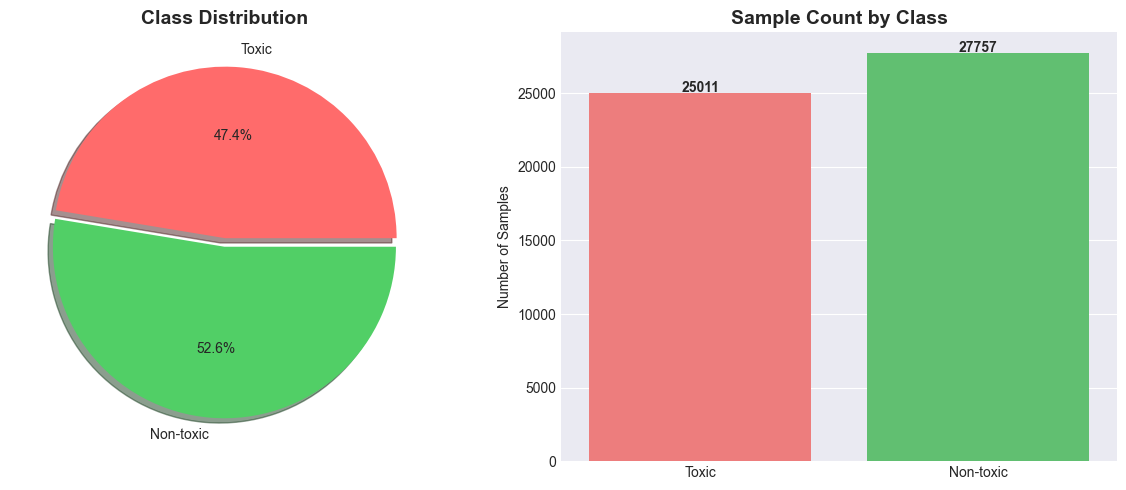


📊 Key Insight: Dataset is balanced


In [3]:
# Class distribution
print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)

toxic_count = len(df[df['toxic']==1])
nontoxic_count = len(df[df['toxic']==0])
total = len(df)

print(f"\n🔴 Toxic samples: {toxic_count} ({toxic_count/total*100:.2f}%)")
print(f"🟢 Non-toxic samples: {nontoxic_count} ({nontoxic_count/total*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([toxic_count, nontoxic_count], 
            labels=['Toxic', 'Non-toxic'],
            colors=['#ff6b6b', '#51cf66'],
            autopct='%1.1f%%',
            explode=(0.05, 0),
            shadow=True)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=['Toxic', 'Non-toxic'], 
            y=[toxic_count, nontoxic_count],
            palette=['#ff6b6b', '#51cf66'],
            ax=axes[1])
axes[1].set_title('Sample Count by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')

# Add value labels on bars
for i, v in enumerate([toxic_count, nontoxic_count]):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Key Insight: Dataset is " + 
      ("balanced" if abs(toxic_count - nontoxic_count)/total < 0.2 else "imbalanced"))

SOURCE DISTRIBUTION

📊 Samples by source:
  hate_speech: 24745 (46.9%)
  jigsaw: 19728 (37.4%)
  paradetox: 8295 (15.7%)

📊 Source vs Toxicity breakdown:
             Non-toxic  Toxic  Total
source                              
hate_speech       4156  20589  24745
jigsaw           18819    909  19728
paradetox         4782   3513   8295
All              27757  25011  52768

📊 Toxicity percentage by source:
             Total Samples  Toxicity %
source                                
hate_speech          24745       83.20
jigsaw               19728        4.61
paradetox             8295       42.35


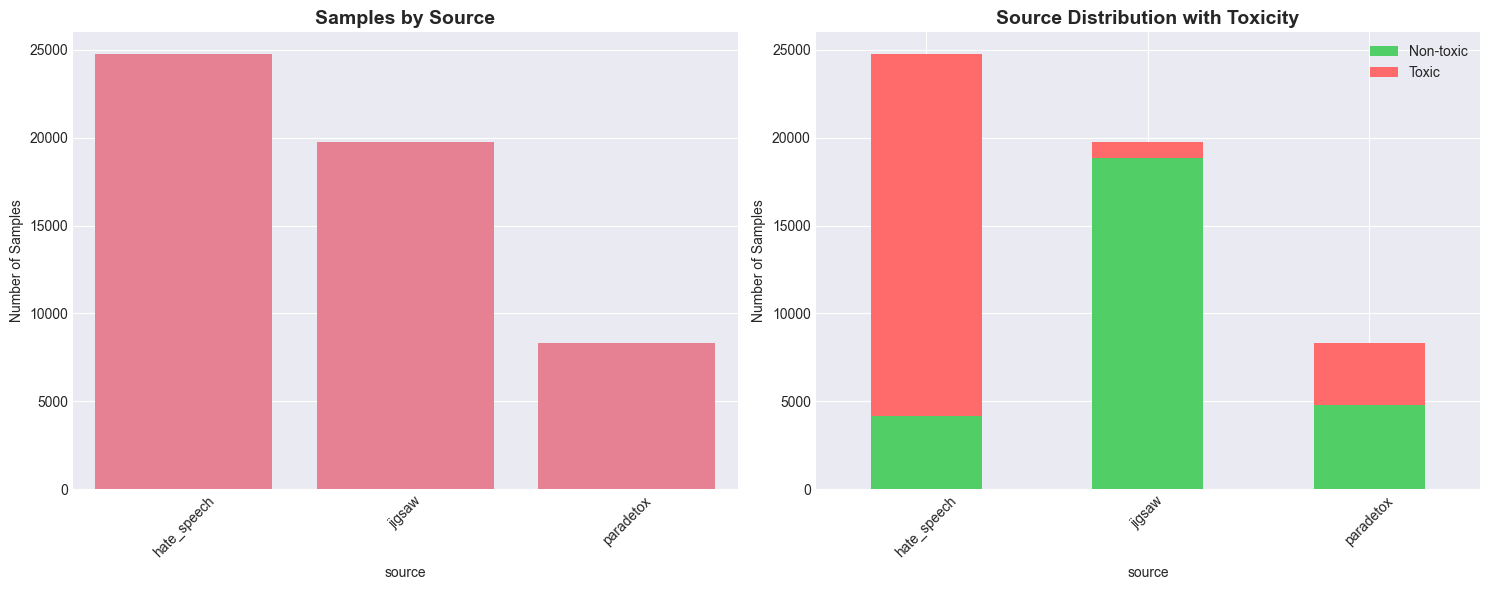


💡 Insight: Different sources have different toxicity rates


In [4]:
# Source distribution
print("="*60)
print("SOURCE DISTRIBUTION")
print("="*60)

source_counts = df['source'].value_counts()
print("\n📊 Samples by source:")
for source, count in source_counts.items():
    print(f"  {source}: {count} ({count/total*100:.1f}%)")

# Source vs Toxicity
source_toxic = pd.crosstab(df['source'], df['toxic'], margins=True)
source_toxic.columns = ['Non-toxic', 'Toxic', 'Total']
print("\n📊 Source vs Toxicity breakdown:")
print(source_toxic)

# Calculate toxicity percentage by source
source_toxic_pct = df.groupby('source')['toxic'].agg(['count', 'mean'])
source_toxic_pct['mean'] = source_toxic_pct['mean'] * 100
source_toxic_pct.columns = ['Total Samples', 'Toxicity %']
print("\n📊 Toxicity percentage by source:")
print(source_toxic_pct.round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Source distribution bar chart
sns.barplot(x=source_counts.index, y=source_counts.values, ax=axes[0])
axes[0].set_title('Samples by Source', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Stacked bar chart: source + toxicity
source_toxic_plot = df.groupby(['source', 'toxic']).size().unstack(fill_value=0)
source_toxic_plot.columns = ['Non-toxic', 'Toxic']
source_toxic_plot.plot(kind='bar', stacked=True, 
                       color=['#51cf66', '#ff6b6b'],
                       ax=axes[1])
axes[1].set_title('Source Distribution with Toxicity', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../results/figures/source_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Different sources have different toxicity rates")

TEXT LENGTH ANALYSIS

📊 Overall statistics:
Average characters: 172.6
Average words: 29.7
Average sentences: 3.1

📊 Statistics by class (mean values):
           char_count  word_count  sentence_count
Non-toxic       249.5        43.1             4.1
Toxic            87.2        15.0             1.9


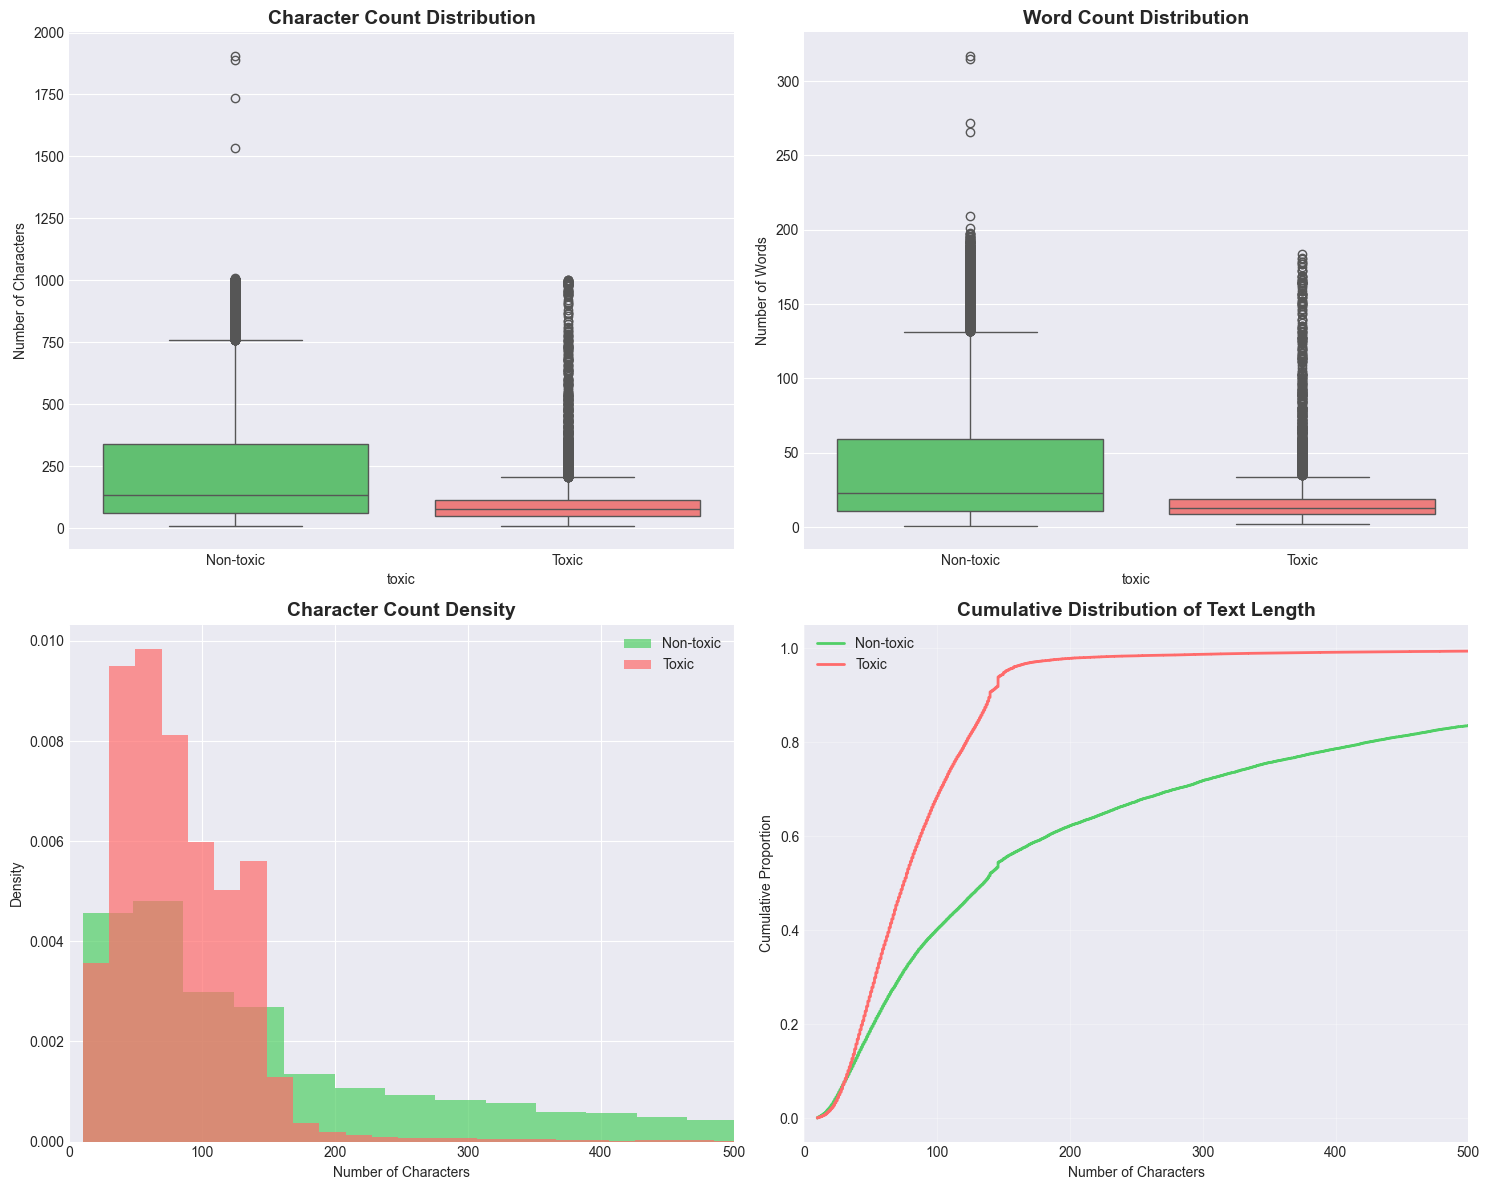


💡 Insight: Non-toxic comments tend to be longer


In [5]:
print("="*60)
print("TEXT LENGTH ANALYSIS")
print("="*60)

# Calculate length features
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['sentence_count'] = df['text'].str.split('[.!?]+').str.len()

print("\n📊 Overall statistics:")
print(f"Average characters: {df['char_count'].mean():.1f}")
print(f"Average words: {df['word_count'].mean():.1f}")
print(f"Average sentences: {df['sentence_count'].mean():.1f}")

# Compare toxic vs non-toxic
print("\n📊 Statistics by class (mean values):")
length_stats = df.groupby('toxic')[['char_count', 'word_count', 'sentence_count']].mean()
length_stats.index = ['Non-toxic', 'Toxic']
print(length_stats.round(1))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plots for character count
sns.boxplot(x='toxic', y='char_count', data=df, 
            palette=['#51cf66', '#ff6b6b'], ax=axes[0,0])
axes[0,0].set_title('Character Count Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,0].set_ylabel('Number of Characters')

# Box plots for word count
sns.boxplot(x='toxic', y='word_count', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[0,1])
axes[0,1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,1].set_ylabel('Number of Words')

# Histogram of character counts
for toxic_val, color, label in [(0, '#51cf66', 'Non-toxic'), (1, '#ff6b6b', 'Toxic')]:
    subset = df[df['toxic'] == toxic_val]['char_count']
    axes[1,0].hist(subset, alpha=0.7, bins=50, color=color, label=label, density=True)
axes[1,0].set_title('Character Count Density', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Characters')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].set_xlim(0, 500)  # Focus on typical range

# Cumulative distribution
for toxic_val, color, label in [(0, '#51cf66', 'Non-toxic'), (1, '#ff6b6b', 'Toxic')]:
    subset = df[df['toxic'] == toxic_val]['char_count']
    sorted_data = np.sort(subset)
    yvals = np.arange(len(sorted_data))/float(len(sorted_data))
    axes[1,1].plot(sorted_data, yvals, color=color, label=label, linewidth=2)
axes[1,1].set_title('Cumulative Distribution of Text Length', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Characters')
axes[1,1].set_ylabel('Cumulative Proportion')
axes[1,1].legend()
axes[1,1].set_xlim(0, 500)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/figures/length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: " + 
      ("Toxic comments tend to be longer" if length_stats.loc['Toxic', 'word_count'] > length_stats.loc['Non-toxic', 'word_count'] 
       else "Non-toxic comments tend to be longer"))

PUNCTUATION & CAPITALIZATION ANALYSIS



📊 Punctuation usage (average per text):
           exclamation_count  question_count  period_count  all_caps_words
Non-toxic               0.19            0.33          3.03            0.47
Toxic                   0.17            0.11          0.95            0.41


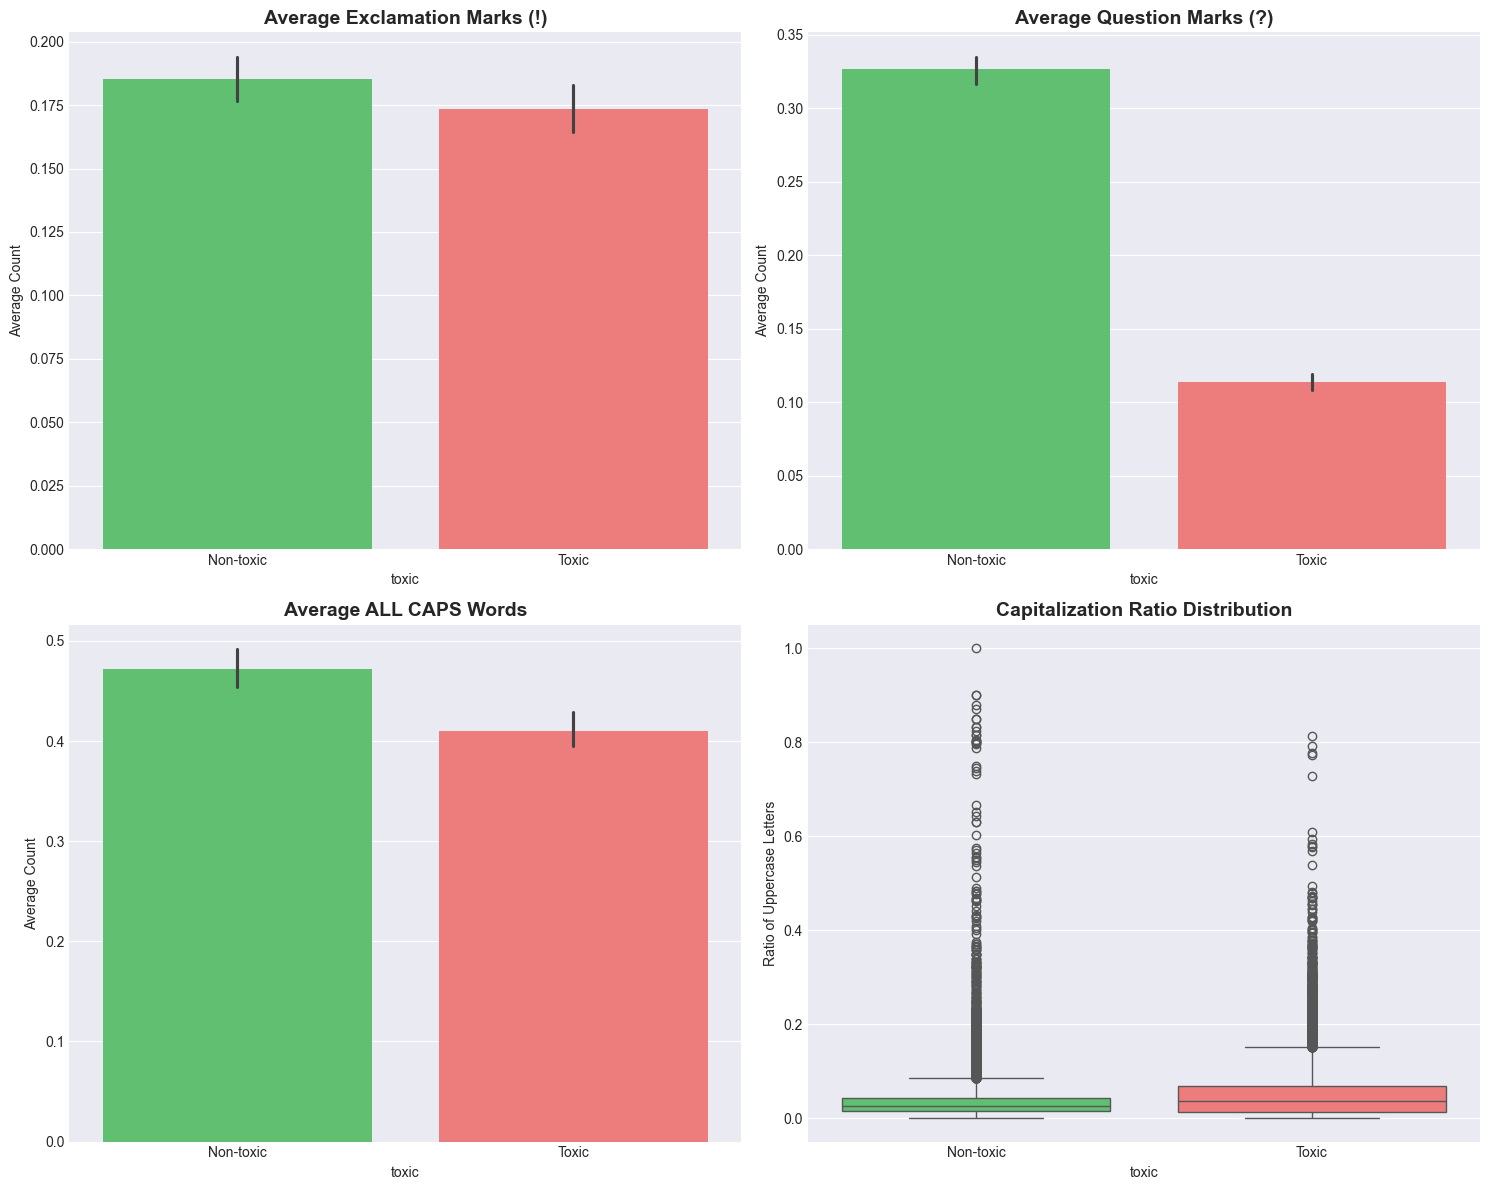


💡 Insight: Toxic comments use similar punctuation patterns


In [6]:
print("="*60)
print("PUNCTUATION & CAPITALIZATION ANALYSIS")
print("="*60)

# Calculate punctuation features
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count('\?')
df['period_count'] = df['text'].str.count('\.')
df['all_caps_words'] = df['text'].str.findall(r'\b[A-Z]{2,}\b').str.len()
df['caps_ratio'] = df['text'].str.findall(r'[A-Z]').str.len() / df['char_count'].clip(lower=1)

print("\n📊 Punctuation usage (average per text):")
punct_stats = df.groupby('toxic')[['exclamation_count', 'question_count', 'period_count', 'all_caps_words']].mean()
punct_stats.index = ['Non-toxic', 'Toxic']
print(punct_stats.round(2))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Exclamation marks
sns.barplot(x='toxic', y='exclamation_count', data=df,
            estimator=lambda x: x.mean(), 
            palette=['#51cf66', '#ff6b6b'], ax=axes[0,0])
axes[0,0].set_title('Average Exclamation Marks (!)', fontsize=14, fontweight='bold')
axes[0,0].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,0].set_ylabel('Average Count')

# Question marks
sns.barplot(x='toxic', y='question_count', data=df,
            estimator=lambda x: x.mean(),
            palette=['#51cf66', '#ff6b6b'], ax=axes[0,1])
axes[0,1].set_title('Average Question Marks (?)', fontsize=14, fontweight='bold')
axes[0,1].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,1].set_ylabel('Average Count')

# ALL CAPS words
sns.barplot(x='toxic', y='all_caps_words', data=df,
            estimator=lambda x: x.mean(),
            palette=['#51cf66', '#ff6b6b'], ax=axes[1,0])
axes[1,0].set_title('Average ALL CAPS Words', fontsize=14, fontweight='bold')
axes[1,0].set_xticklabels(['Non-toxic', 'Toxic'])
axes[1,0].set_ylabel('Average Count')

# Capitalization ratio
sns.boxplot(x='toxic', y='caps_ratio', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[1,1])
axes[1,1].set_title('Capitalization Ratio Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xticklabels(['Non-toxic', 'Toxic'])
axes[1,1].set_ylabel('Ratio of Uppercase Letters')

plt.tight_layout()
plt.savefig('../../results/figures/punctuation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Toxic comments use " + 
      ("more exclamation marks and ALL CAPS" if punct_stats.loc['Toxic', 'exclamation_count'] > punct_stats.loc['Non-toxic', 'exclamation_count'] 
       else "similar punctuation patterns"))

SENTIMENT ANALYSIS
Calculating sentiment scores...



📊 Average sentiment by class:
           sentiment_compound  sentiment_positive  sentiment_negative  \
Non-toxic               0.064               0.110               0.091   
Toxic                  -0.323               0.092               0.259   

           sentiment_neutral  
Non-toxic              0.799  
Toxic                  0.649  


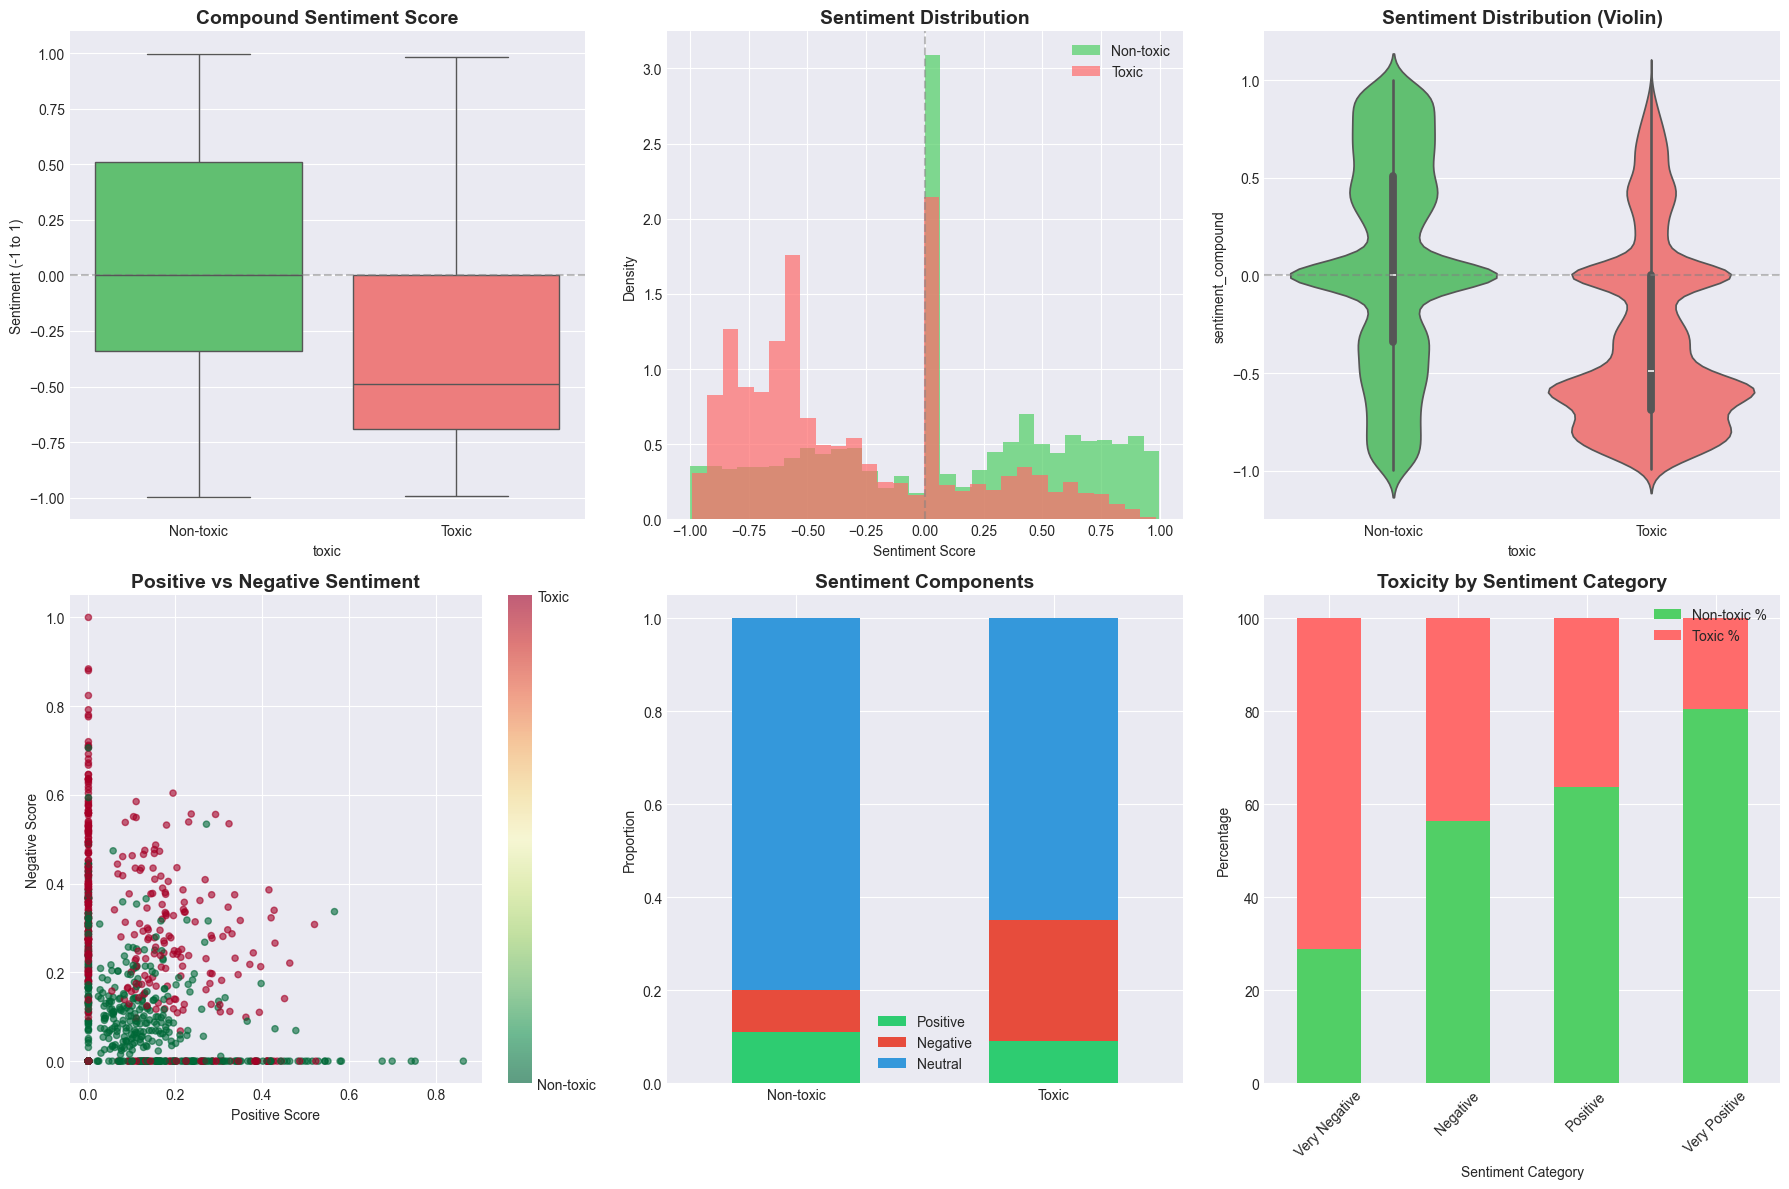


💡 Key Insights:
  • Non-toxic comments average sentiment: 0.064
  • Toxic comments average sentiment: -0.323
  • 19.2% of toxic comments have positive sentiment


In [7]:
print("="*60)
print("SENTIMENT ANALYSIS")
print("="*60)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment (this may take a minute)
print("Calculating sentiment scores...")
df['sentiment_compound'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment_positive'] = df['text'].apply(lambda x: sia.polarity_scores(x)['pos'])
df['sentiment_negative'] = df['text'].apply(lambda x: sia.polarity_scores(x)['neg'])
df['sentiment_neutral'] = df['text'].apply(lambda x: sia.polarity_scores(x)['neu'])

print("\n📊 Average sentiment by class:")
sentiment_stats = df.groupby('toxic')[['sentiment_compound', 'sentiment_positive', 
                                       'sentiment_negative', 'sentiment_neutral']].mean()
sentiment_stats.index = ['Non-toxic', 'Toxic']
print(sentiment_stats.round(3))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Box plot of compound sentiment
sns.boxplot(x='toxic', y='sentiment_compound', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[0,0])
axes[0,0].set_title('Compound Sentiment Score', fontsize=14, fontweight='bold')
axes[0,0].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,0].set_ylabel('Sentiment (-1 to 1)')
axes[0,0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 2. Histogram of sentiment
for toxic_val, color, label in [(0, '#51cf66', 'Non-toxic'), (1, '#ff6b6b', 'Toxic')]:
    subset = df[df['toxic'] == toxic_val]['sentiment_compound']
    axes[0,1].hist(subset, alpha=0.7, bins=30, color=color, label=label, density=True)
axes[0,1].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Sentiment Score')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()
axes[0,1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 3. Violin plot
sns.violinplot(x='toxic', y='sentiment_compound', data=df,
               palette=['#51cf66', '#ff6b6b'], ax=axes[0,2])
axes[0,2].set_title('Sentiment Distribution (Violin)', fontsize=14, fontweight='bold')
axes[0,2].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0,2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 4. Positive vs Negative scatter (sample for visualization)
sample_df = df.sample(n=min(1000, len(df)), random_state=42)
axes[1,0].scatter(sample_df['sentiment_positive'], sample_df['sentiment_negative'],
                  c=sample_df['toxic'], cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1,0].set_xlabel('Positive Score')
axes[1,0].set_ylabel('Negative Score')
axes[1,0].set_title('Positive vs Negative Sentiment', fontsize=14, fontweight='bold')
# Add colorbar
from matplotlib.colors import ListedColormap
cbar = plt.colorbar(axes[1,0].collections[0], ax=axes[1,0])
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Non-toxic', 'Toxic'])

# 5. Sentiment components stacked bar
components = pd.DataFrame({
    'Non-toxic': sentiment_stats.loc['Non-toxic', ['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].values,
    'Toxic': sentiment_stats.loc['Toxic', ['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].values
}, index=['Positive', 'Negative', 'Neutral'])

components.T.plot(kind='bar', stacked=True, 
                  color=['#2ecc71', '#e74c3c', '#3498db'],
                  ax=axes[1,1])
axes[1,1].set_title('Sentiment Components', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Proportion')
axes[1,1].set_xticklabels(['Non-toxic', 'Toxic'], rotation=0)

# 6. Relationship between sentiment and toxicity
# Create sentiment categories
df['sentiment_category'] = pd.cut(df['sentiment_compound'], 
                                   bins=[-1, -0.5, 0, 0.5, 1],
                                   labels=['Very Negative', 'Negative', 'Positive', 'Very Positive'])
sentiment_toxicity = pd.crosstab(df['sentiment_category'], df['toxic'], normalize='index') * 100
sentiment_toxicity.columns = ['Non-toxic %', 'Toxic %']
sentiment_toxicity.plot(kind='bar', stacked=True,
                        color=['#51cf66', '#ff6b6b'],
                        ax=axes[1,2])
axes[1,2].set_title('Toxicity by Sentiment Category', fontsize=14, fontweight='bold')
axes[1,2].set_ylabel('Percentage')
axes[1,2].set_xlabel('Sentiment Category')
axes[1,2].legend(loc='upper right')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../../results/figures/sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Key Insights:")
print("  • Non-toxic comments average sentiment: {:.3f}".format(sentiment_stats.loc['Non-toxic', 'sentiment_compound']))
print("  • Toxic comments average sentiment: {:.3f}".format(sentiment_stats.loc['Toxic', 'sentiment_compound']))
print("  • {}% of toxic comments have positive sentiment".format(
    round(len(df[(df['toxic']==1) & (df['sentiment_compound']>0)])/len(df[df['toxic']==1])*100, 1)))

MOST COMMON WORDS ANALYSIS
Processing words (this may take a moment)...



🔴 Top 20 words in TOXIC comments:
  bitch: 8370
  bitches: 3105
  hoes: 2377
  pussy: 2146
  http: 1936
  hoe: 1882
  ass: 1738
  fuck: 1620
  shit: 1577
  got: 1559
  nigga: 1240
  lol: 1056
  know: 877
  niggas: 787
  fucking: 756
  amp: 753
  people: 696
  love: 669
  stupid: 642
  bad: 594

🟢 Top 20 words in NON-TOXIC comments:
  people: 4446
  think: 2203
  time: 2024
  state: 1991
  good: 1955
  know: 1910
  many: 1785
  see: 1717
  even: 1655
  make: 1641
  need: 1542
  want: 1529
  much: 1502
  right: 1489
  http: 1470
  way: 1464
  well: 1410
  years: 1410
  money: 1379
  public: 1281


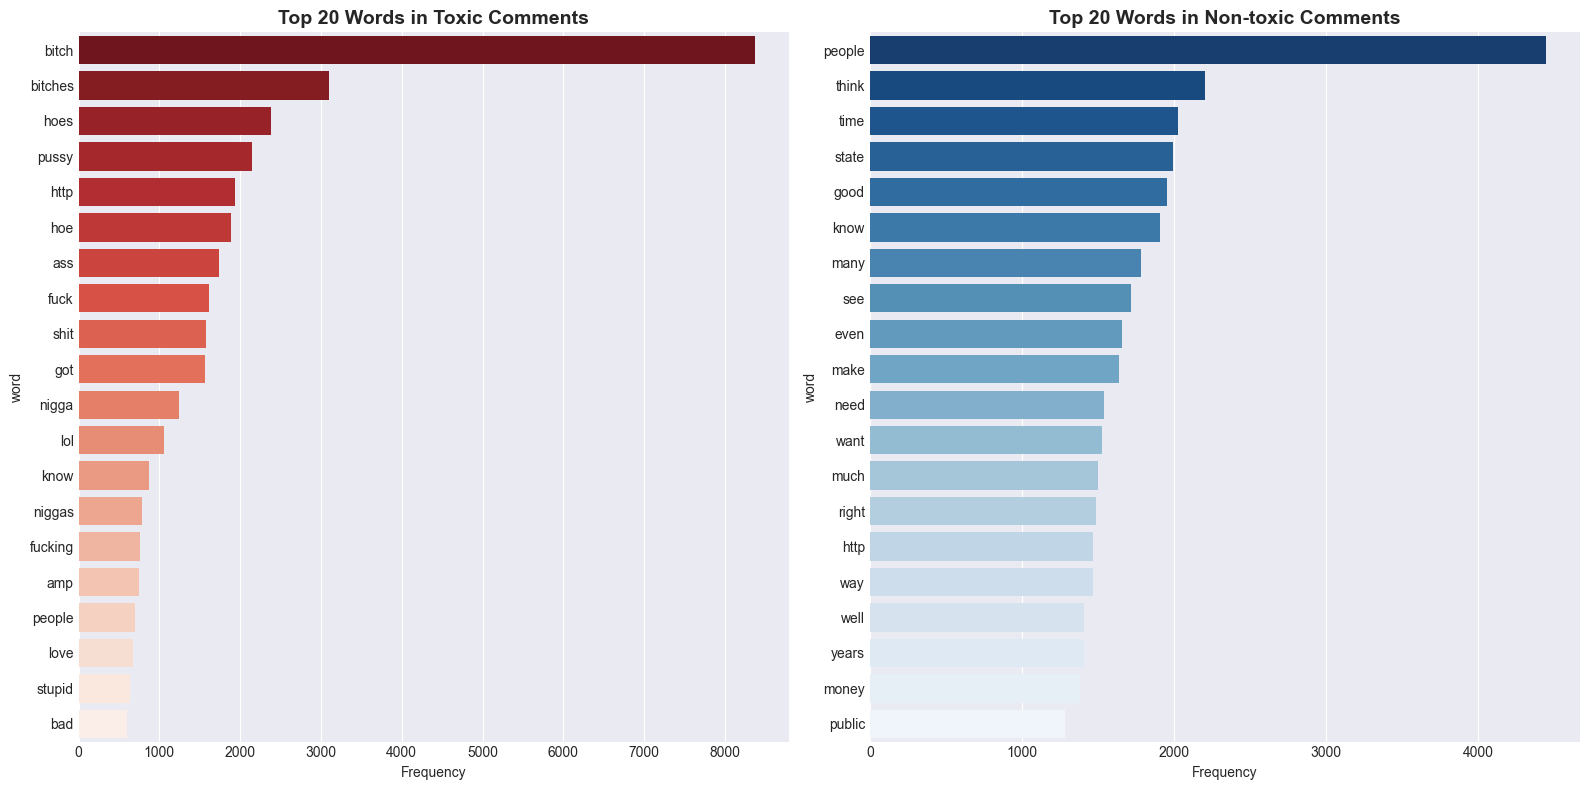


💡 Insight: Toxic comments often contain profanity and insults, while non-toxic comments have more neutral/content words


In [8]:
print("="*60)
print("MOST COMMON WORDS ANALYSIS")
print("="*60)

# Setup
stop_words = set(stopwords.words('english'))
# Add custom stopwords if needed
custom_stops = ['get', 'like', 'one', 'would', 'could', 'also', 'really']
stop_words.update(custom_stops)

def get_clean_words(text, toxic_label):
    """Extract clean words from text"""
    if pd.isna(text) or not isinstance(text, str):
        return []
    
    # Tokenize and clean
    words = word_tokenize(text.lower())
    # Remove punctuation, stopwords, and short words
    words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 2]
    return words

# Get words by class
print("Processing words (this may take a moment)...")
toxic_words = []
nontoxic_words = []

for idx, row in df.iterrows():
    words = get_clean_words(row['text'], row['toxic'])
    if row['toxic'] == 1:
        toxic_words.extend(words)
    else:
        nontoxic_words.extend(words)

# Get top words
toxic_top = Counter(toxic_words).most_common(20)
nontoxic_top = Counter(nontoxic_words).most_common(20)

print("\n🔴 Top 20 words in TOXIC comments:")
for word, count in toxic_top:
    print(f"  {word}: {count}")

print("\n🟢 Top 20 words in NON-TOXIC comments:")
for word, count in nontoxic_top:
    print(f"  {word}: {count}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Toxic words
toxic_words_df = pd.DataFrame(toxic_top, columns=['word', 'count'])
sns.barplot(x='count', y='word', data=toxic_words_df, 
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 20 Words in Toxic Comments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Non-toxic words
nontoxic_words_df = pd.DataFrame(nontoxic_top, columns=['word', 'count'])
sns.barplot(x='count', y='word', data=nontoxic_words_df,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 20 Words in Non-toxic Comments', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../../results/figures/top_words.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Toxic comments often contain profanity and insults, while non-toxic comments have more neutral/content words")

WORD CLOUDS VISUALIZATION


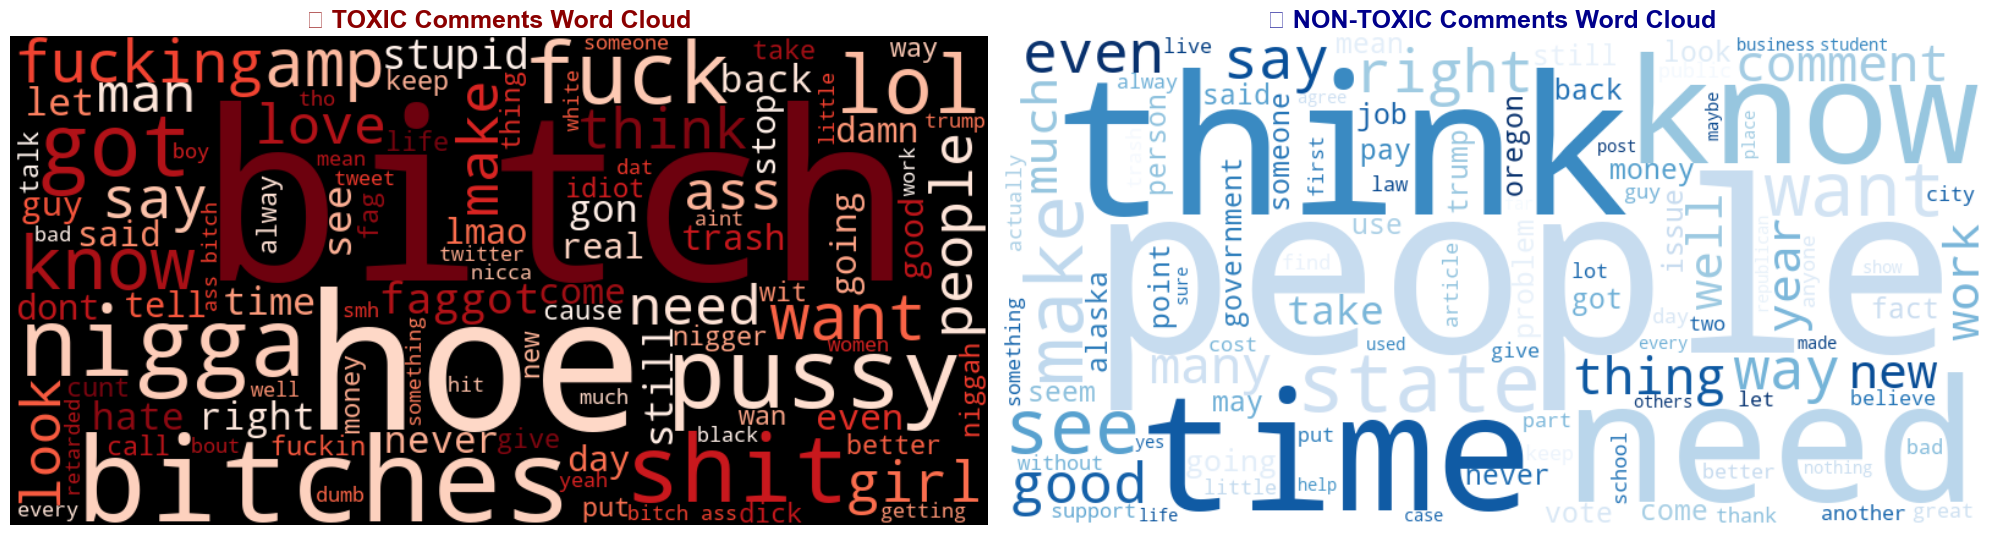


📊 Word cloud generated successfully


In [9]:
print("="*60)
print("WORD CLOUDS VISUALIZATION")
print("="*60)

# Prepare text for word clouds
def get_wordcloud_text(word_list):
    return ' '.join(word_list)

# Create word clouds
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Toxic word cloud
toxic_text = get_wordcloud_text(toxic_words)
wordcloud_toxic = WordCloud(width=800, height=400, 
                           background_color='black',
                           colormap='Reds',
                           max_words=100,
                           contour_width=1,
                           contour_color='darkred').generate(toxic_text)

axes[0].imshow(wordcloud_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🔴 TOXIC Comments Word Cloud', fontsize=18, fontweight='bold', color='darkred')

# Non-toxic word cloud
nontoxic_text = get_wordcloud_text(nontoxic_words)
wordcloud_nontoxic = WordCloud(width=800, height=400,
                              background_color='white',
                              colormap='Blues',
                              max_words=100,
                              contour_width=1,
                              contour_color='darkblue').generate(nontoxic_text)

axes[1].imshow(wordcloud_nontoxic, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🟢 NON-TOXIC Comments Word Cloud', fontsize=18, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('../../results/figures/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Word cloud generated successfully")

N-GRAM ANALYSIS
Extracting bigrams...

🔴 Top 15 bigrams in TOXIC comments:
  bitch ass: 243
  ass bitch: 193
  bad bitch: 183
  bitch http: 178
  fuck bitch: 166
  bad bitches: 146
  ass nigga: 131
  little bitch: 125
  bitch got: 113
  eat pussy: 101
  white trash: 100
  bitch nigga: 99
  lil bitch: 97
  got hoes: 88
  dumb bitch: 80

🟢 Top 15 bigrams in NON-TOXIC comments:
  minimum wage: 220
  years ago: 202
  supreme court: 194
  high school: 155
  many people: 154
  united states: 150
  income tax: 145
  lane county: 142
  law enforcement: 138
  federal government: 105
  even though: 104
  health care: 100
  property taxes: 93
  civil comments: 91
  sales tax: 90


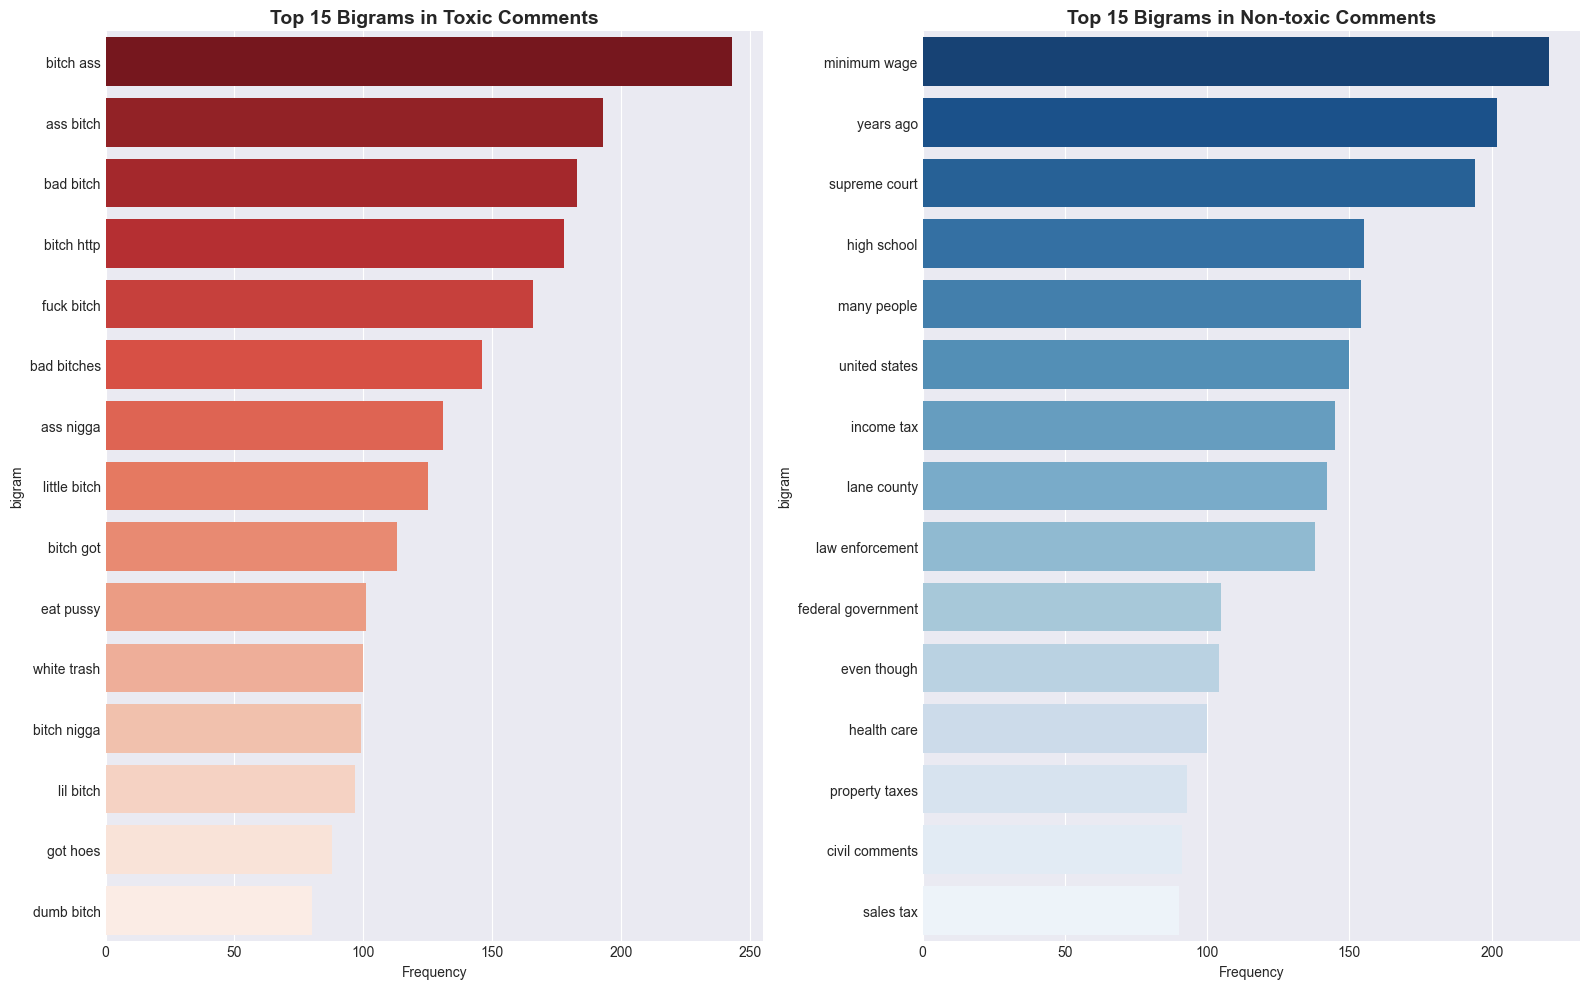


💡 Insight: Common phrases reveal context and patterns of toxicity


In [10]:
print("="*60)
print("N-GRAM ANALYSIS")
print("="*60)

def get_ngrams(text, n=2):
    """Extract n-grams from text"""
    if pd.isna(text) or not isinstance(text, str):
        return []
    
    words = word_tokenize(text.lower())
    words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 2]
    n_grams = list(ngrams(words, n))
    return [' '.join(gram) for gram in n_grams]

# Get bigrams
print("Extracting bigrams...")
toxic_bigrams = []
nontoxic_bigrams = []

for idx, row in df.iterrows():
    bigrams = get_ngrams(row['text'], 2)
    if row['toxic'] == 1:
        toxic_bigrams.extend(bigrams)
    else:
        nontoxic_bigrams.extend(bigrams)

# Top bigrams
toxic_bigram_top = Counter(toxic_bigrams).most_common(15)
nontoxic_bigram_top = Counter(nontoxic_bigrams).most_common(15)

print("\n🔴 Top 15 bigrams in TOXIC comments:")
for bigram, count in toxic_bigram_top:
    print(f"  {bigram}: {count}")

print("\n🟢 Top 15 bigrams in NON-TOXIC comments:")
for bigram, count in nontoxic_bigram_top:
    print(f"  {bigram}: {count}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Toxic bigrams
toxic_bigram_df = pd.DataFrame(toxic_bigram_top, columns=['bigram', 'count'])
sns.barplot(x='count', y='bigram', data=toxic_bigram_df,
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 15 Bigrams in Toxic Comments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Non-toxic bigrams
nontoxic_bigram_df = pd.DataFrame(nontoxic_bigram_top, columns=['bigram', 'count'])
sns.barplot(x='count', y='bigram', data=nontoxic_bigram_df,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 15 Bigrams in Non-toxic Comments', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../../results/figures/bigrams.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Common phrases reveal context and patterns of toxicity")

Extracting 3-grams...

🔴 Top 15 3-grams in TOXIC comments:
  bitch ass nigga: 53
  porn android iphone: 45
  android iphone ipad: 45
  iphone ipad sex: 45
  ipad sex xxx: 45
  fuck right pussy: 26
  bad bitches thing: 23
  stupid ass bitch: 23
  hoe ass nigga: 21
  type bad bitches: 16
  bitch bitch bitch: 15
  got type bad: 14
  boss ass bitch: 13
  big booty bitches: 13
  cunt cunt cunt: 13

🟢 Top 15 3-grams in NON-TOXIC comments:
  hugh massengill eugene: 51
  black lives matter: 24
  best asian massage: 19
  park slope top: 19
  slope top rated: 19
  top rated spa: 19
  rated spa http: 19
  federal minimum wage: 19
  state income tax: 18
  oil tax credits: 18
  oregon state police: 15
  eugene city council: 15
  supreme court justice: 15
  barack hussein obama: 15
  high density planning: 15


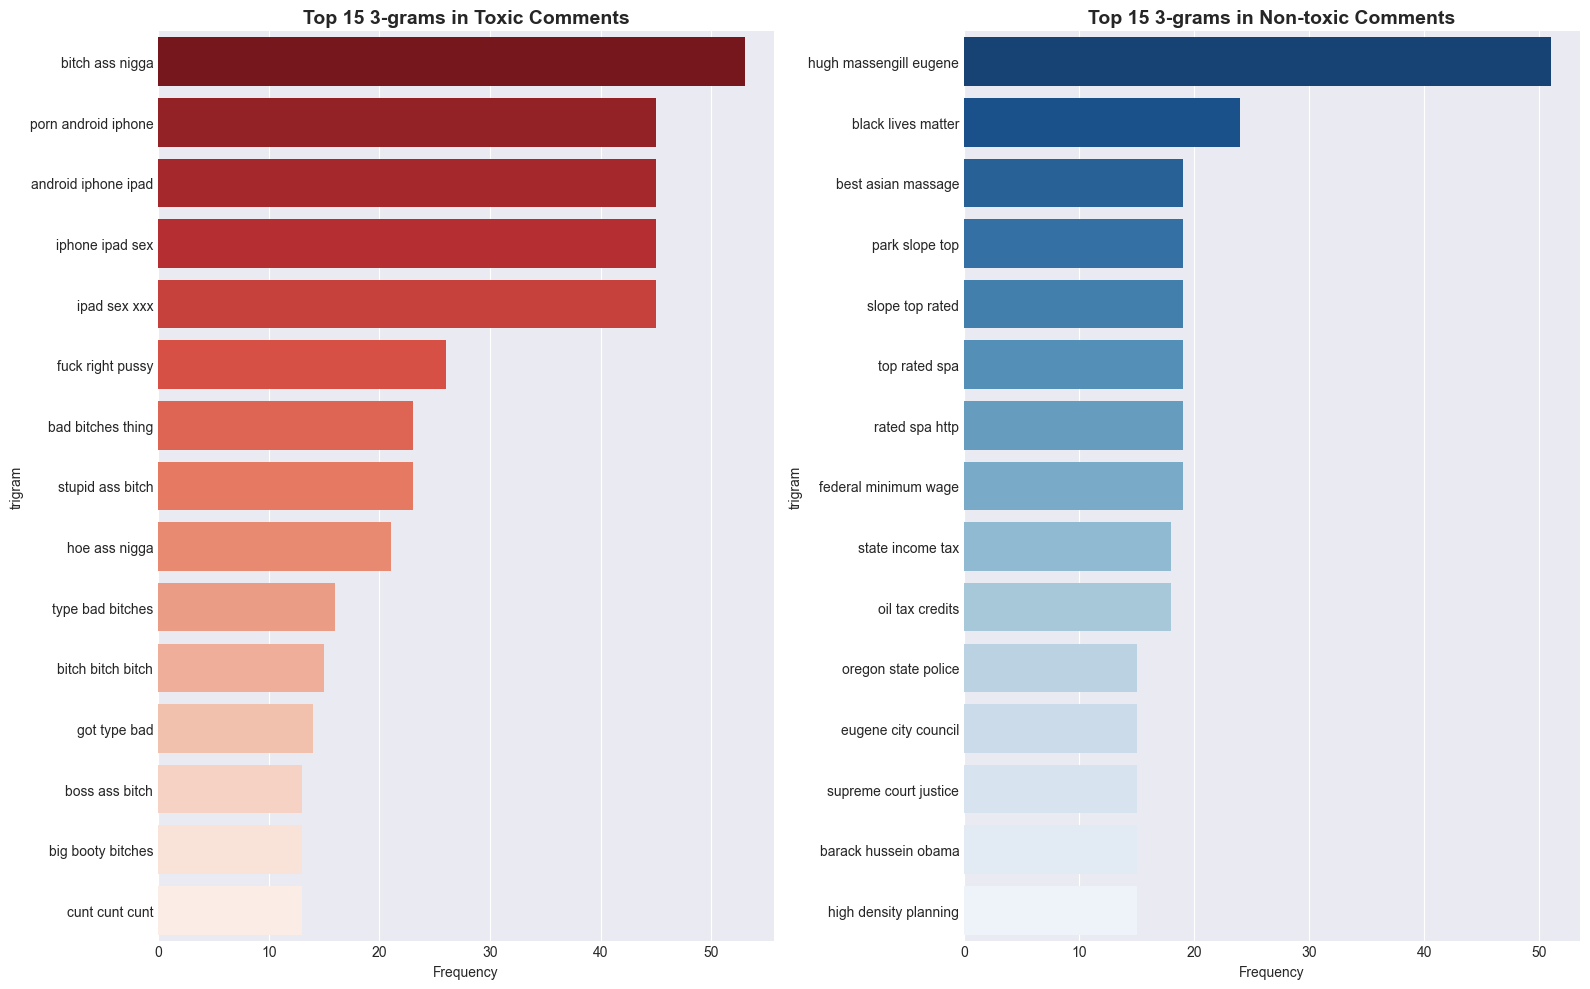


💡 Insight: Common 3-word phrases reveal contextual toxicity patterns.


In [11]:
# Get trigrams
print("Extracting 3-grams...")
toxic_trigrams = []
nontoxic_trigrams = []

for idx, row in df.iterrows():
    trigrams = get_ngrams(row['text'], 3)   # changed from 2 → 3
    if row['toxic'] == 1:
        toxic_trigrams.extend(trigrams)
    else:
        nontoxic_trigrams.extend(trigrams)

# Top trigrams
toxic_trigram_top = Counter(toxic_trigrams).most_common(15)
nontoxic_trigram_top = Counter(nontoxic_trigrams).most_common(15)

print("\n🔴 Top 15 3-grams in TOXIC comments:")
for trigram, count in toxic_trigram_top:
    print(f"  {trigram}: {count}")

print("\n🟢 Top 15 3-grams in NON-TOXIC comments:")
for trigram, count in nontoxic_trigram_top:
    print(f"  {trigram}: {count}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Toxic trigrams
toxic_trigram_df = pd.DataFrame(toxic_trigram_top, columns=['trigram', 'count'])
sns.barplot(x='count', y='trigram', data=toxic_trigram_df,
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 15 3-grams in Toxic Comments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Non-toxic trigrams
nontoxic_trigram_df = pd.DataFrame(nontoxic_trigram_top, columns=['trigram', 'count'])
sns.barplot(x='count', y='trigram', data=nontoxic_trigram_df,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 15 3-grams in Non-toxic Comments', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../../results/figures/3-grams.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Common 3-word phrases reveal contextual toxicity patterns.")

READABILITY ANALYSIS
Calculating readability scores for 52768 comments...



📊 Average readability scores:
           flesch_score  fog_index  smog_index
Non-toxic          67.1        9.4         9.3
Toxic              77.9        7.4         7.0


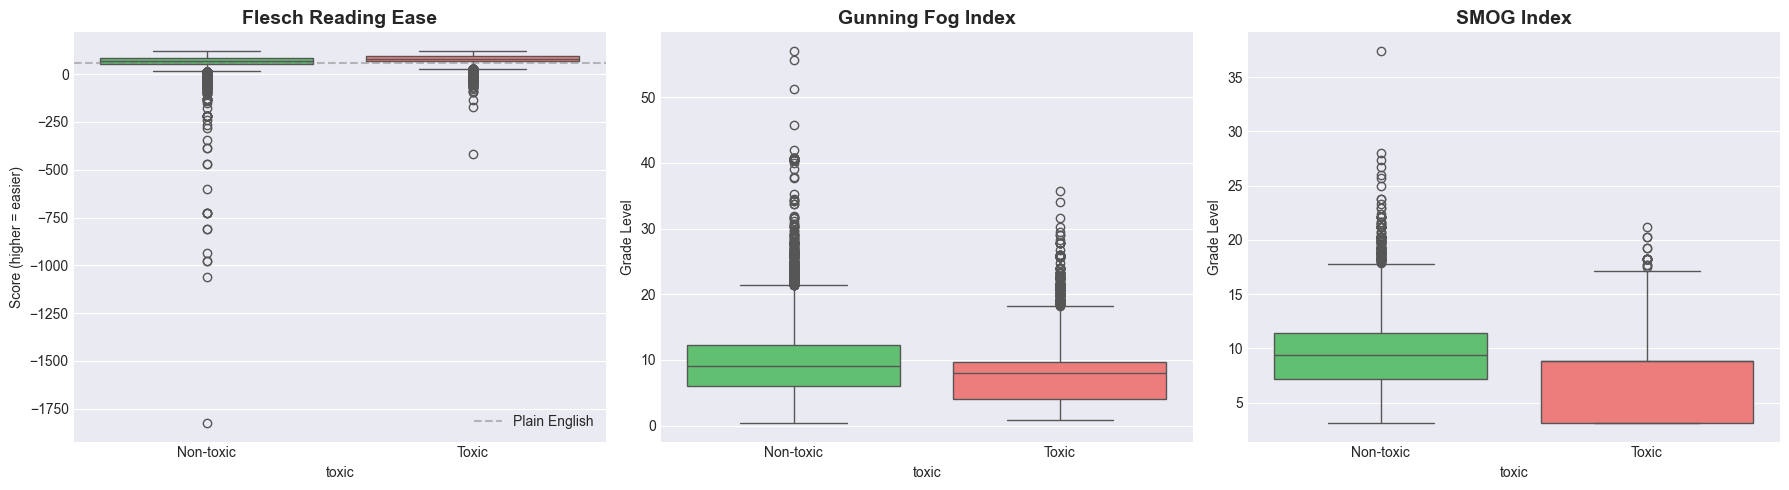


💡 Insight: Toxic and non-toxic comments have similar readability


In [13]:
print("="*60)
print("READABILITY ANALYSIS")
print("="*60)

print(f"Calculating readability scores for {len(df)} comments...")

# Flesch Reading Ease (higher = easier to read)
df['flesch_score'] = df['text'].apply(lambda x: textstat.flesch_reading_ease(str(x)))

# Gunning Fog Index (grade level)
df['fog_index'] = df['text'].apply(lambda x: textstat.gunning_fog(str(x)))

# SMOG Index
df['smog_index'] = df['text'].apply(lambda x: textstat.smog_index(str(x)))

# Compare by class
print("\n📊 Average readability scores:")
readability_stats = df.groupby('toxic')[['flesch_score', 'fog_index', 'smog_index']].mean()
readability_stats.index = ['Non-toxic', 'Toxic']
print(readability_stats.round(1))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Flesch score
sns.boxplot(x='toxic', y='flesch_score', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[0])
axes[0].set_title('Flesch Reading Ease', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Non-toxic', 'Toxic'])
axes[0].set_ylabel('Score (higher = easier)')
axes[0].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='Plain English')
axes[0].legend()

# Fog index
sns.boxplot(x='toxic', y='fog_index', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[1])
axes[1].set_title('Gunning Fog Index', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Non-toxic', 'Toxic'])
axes[1].set_ylabel('Grade Level')

# SMOG index
sns.boxplot(x='toxic', y='smog_index', data=df,
            palette=['#51cf66', '#ff6b6b'], ax=axes[2])
axes[2].set_title('SMOG Index', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(['Non-toxic', 'Toxic'])
axes[2].set_ylabel('Grade Level')

plt.tight_layout()
plt.savefig('../../results/figures/readability.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: " + 
      ("Toxic comments are harder to read" if readability_stats.loc['Toxic', 'flesch_score'] < readability_stats.loc['Non-toxic', 'flesch_score']
       else "Toxic and non-toxic comments have similar readability"))

SOURCE COMPARISON

📊 Feature comparison across sources:
             Toxicity Rate  Avg Characters  Avg Words  Avg Exclamations  \
source                                                                    
hate_speech          0.832          85.555     14.136             0.177   
jigsaw               0.046         332.141     57.402             0.218   
paradetox            0.424          52.778     10.522             0.098   

             Avg Questions  Avg ALL CAPS  Avg Sentiment  
source                                                   
hate_speech          0.104         0.496         -0.261  
jigsaw               0.432         0.560          0.075  
paradetox            0.097         0.006         -0.159  


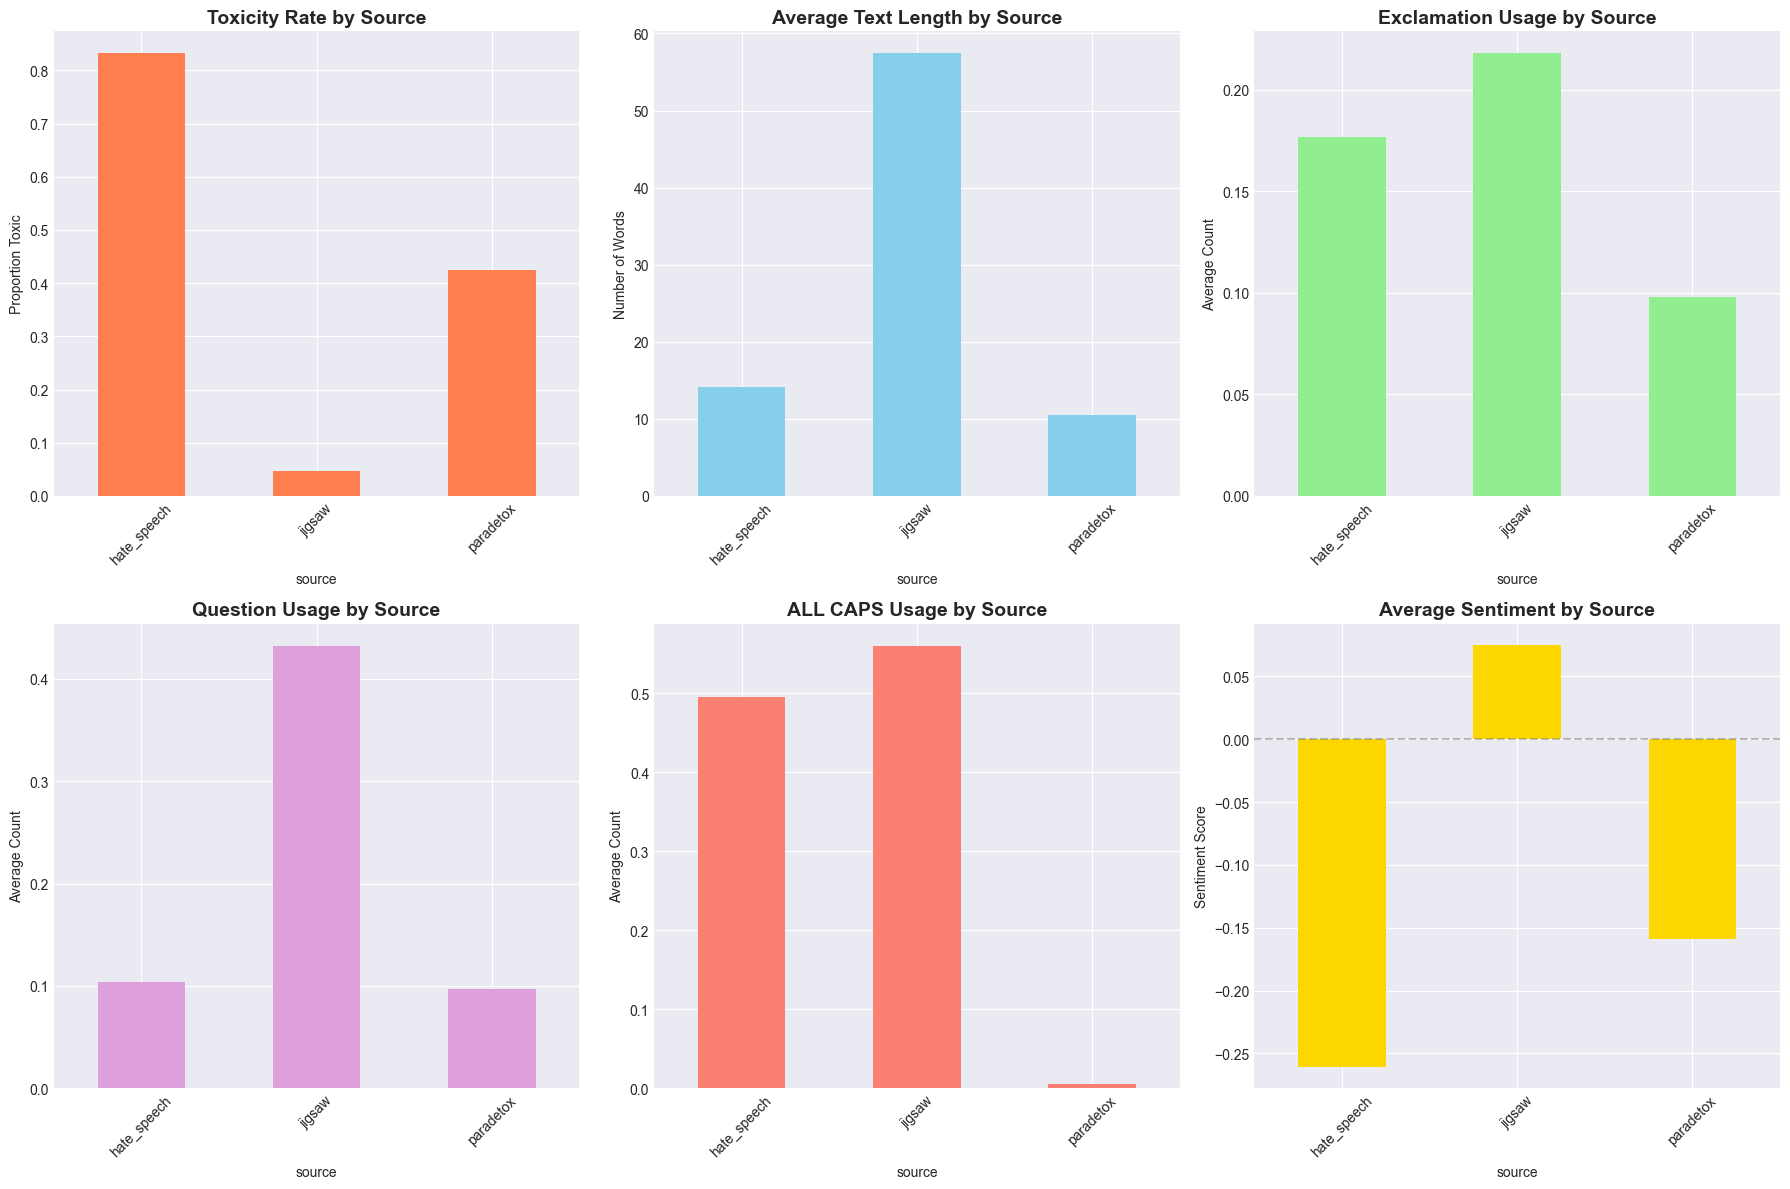


💡 Key Insight: Different data sources have distinct linguistic characteristics


In [16]:
print("="*60)
print("SOURCE COMPARISON")
print("="*60)

# Compare linguistic features across sources
source_features = df.groupby('source').agg({
    'toxic': 'mean',
    'char_count': 'mean',
    'word_count': 'mean',
    'exclamation_count': 'mean',
    'question_count': 'mean',
    'all_caps_words': 'mean',
    'sentiment_compound': 'mean'
}).round(3)

source_features.columns = ['Toxicity Rate', 'Avg Characters', 'Avg Words', 
                          'Avg Exclamations', 'Avg Questions', 'Avg ALL CAPS', 'Avg Sentiment']
print("\n📊 Feature comparison across sources:")
print(source_features)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Toxicity rate
source_features['Toxicity Rate'].plot(kind='bar', ax=axes[0,0], color='coral')
axes[0,0].set_title('Toxicity Rate by Source', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Proportion Toxic')
axes[0,0].tick_params(axis='x', rotation=45)

# Average words
source_features['Avg Words'].plot(kind='bar', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Average Text Length by Source', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Words')
axes[0,1].tick_params(axis='x', rotation=45)

# Exclamations
source_features['Avg Exclamations'].plot(kind='bar', ax=axes[0,2], color='lightgreen')
axes[0,2].set_title('Exclamation Usage by Source', fontsize=14, fontweight='bold')
axes[0,2].set_ylabel('Average Count')
axes[0,2].tick_params(axis='x', rotation=45)

# Questions
source_features['Avg Questions'].plot(kind='bar', ax=axes[1,0], color='plum')
axes[1,0].set_title('Question Usage by Source', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Average Count')
axes[1,0].tick_params(axis='x', rotation=45)

# ALL CAPS
source_features['Avg ALL CAPS'].plot(kind='bar', ax=axes[1,1], color='salmon')
axes[1,1].set_title('ALL CAPS Usage by Source', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Average Count')
axes[1,1].tick_params(axis='x', rotation=45)

# Sentiment
source_features['Avg Sentiment'].plot(kind='bar', ax=axes[1,2], color='gold')
axes[1,2].set_title('Average Sentiment by Source', fontsize=14, fontweight='bold')
axes[1,2].set_ylabel('Sentiment Score')
axes[1,2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../results/figures/source_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Key Insight: Different data sources have distinct linguistic characteristics")

In [14]:
print("="*60)
print("SAVING ENHANCED DATASET WITH ENGINEERED FEATURES")
print("="*60)

# Check what columns we have now vs original
original_columns = ['text', 'toxic', 'source']
new_columns = [col for col in df.columns if col not in original_columns]

print(f"\n📊 Original columns: {original_columns}")
print(f"\n✨ New engineered features ({len(new_columns)}):")
for col in new_columns:
    # Get column type and example
    example = df[col].iloc[0]
    col_type = type(example).__name__
    print(f"  • {col}: {col_type} (example: {example})")

# Group features by category
feature_categories = {
    'length_features': ['char_count', 'word_count', 'sentence_count'],
    'punctuation_features': ['exclamation_count', 'question_count', 'period_count', 'all_caps_words', 'caps_ratio'],
    'sentiment_features': ['sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_category'],
    'readability_features': ['flesch_score', 'fog_index', 'smog_index']
}

print("\n📋 Features by category:")
for category, features in feature_categories.items():
    # Only show features that actually exist in df
    existing = [f for f in features if f in df.columns]
    if existing:
        print(f"\n  {category}:")
        for feat in existing:
            print(f"    - {feat}")

# Save the enhanced dataset
output_path = "../../data/processed/toxiguard_with_engineered_features.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Enhanced dataset saved to: {output_path}")
print(f"   Shape: {df.shape} (original was {len(df)} samples, now with {len(new_columns)} additional features)")

# Show sample of new features
print("\n👀 Sample of new features (first 3 rows):")
display(df[['text', 'toxic'] + new_columns[:5]].head(3))

# Quick statistics on new features
print("\n📊 Statistics of new numerical features:")
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['toxic']]  # exclude target
print(df[numeric_features].describe().round(3))

SAVING ENHANCED DATASET WITH ENGINEERED FEATURES

📊 Original columns: ['text', 'toxic', 'source']

✨ New engineered features (16):
  • char_count: int64 (example: 140)
  • word_count: int64 (example: 25)
  • sentence_count: int64 (example: 4)
  • exclamation_count: int64 (example: 3)
  • question_count: int64 (example: 0)
  • period_count: int64 (example: 4)
  • all_caps_words: int64 (example: 1)
  • caps_ratio: float64 (example: 0.02142857142857143)
  • sentiment_compound: float64 (example: 0.4563)
  • sentiment_positive: float64 (example: 0.12)
  • sentiment_negative: float64 (example: 0.0)
  • sentiment_neutral: float64 (example: 0.88)
  • sentiment_category: str (example: Positive)
  • flesch_score: float64 (example: 81.85500000000002)
  • fog_index: float64 (example: 6.466666666666668)
  • smog_index: float64 (example: 7.168621630094336)

📋 Features by category:

  length_features:
    - char_count
    - word_count
    - sentence_count

  punctuation_features:
    - exclamation_co


✅ Enhanced dataset saved to: ../../data/processed/toxiguard_with_engineered_features.csv
   Shape: (52768, 19) (original was 52768 samples, now with 16 additional features)

👀 Sample of new features (first 3 rows):


,text,toxic,char_count,word_count,sentence_count,exclamation_count,question_count
0,!!! RT @mayasolovely: As a woman you shouldn't...,0,140,25,4,3,0
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,85,16,4,7,0
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,120,21,4,11,1



📊 Statistics of new numerical features:
       char_count  word_count  sentence_count  exclamation_count  \
count   52768.000   52768.000       52768.000          52768.000   
mean      172.592      29.744           3.061              0.180   
std       215.478      36.995           2.689              0.745   
min        10.000       1.000           1.000              0.000   
25%        54.000       9.000           1.000              0.000   
50%        93.000      16.000           2.000              0.000   
75%       157.000      27.000           4.000              0.000   
max      1906.000     317.000          62.000             35.000   

       question_count  period_count  all_caps_words  caps_ratio  \
count       52768.000     52768.000       52768.000   52768.000   
mean            0.226         2.047           0.443       0.042   
std             0.659         3.342           1.473       0.049   
min             0.000         0.000           0.000       0.000   
25%        